In [1]:
# pip install torch
input_value = [1,2,3]
# memory
8 * 3

24

In [2]:
import torch as tc
import numpy as np

v = tc.tensor(input_value, dtype=tc.float32)

print('dtype:', v.dtype)
print('shape:', v.shape)
print('dim', v.dim())

# #memory
# 4 * 3
# indexing
print('indexing:', v[0], v[1], v[2])

# slicing
print('slice 1:4:', v[1:4])
print('slice :3:', v[:3])
print('slice 3::', v[3:])

dtype: torch.float32
shape: torch.Size([3])
dim 1
indexing: tensor(1.) tensor(2.) tensor(3.)
slice 1:4: tensor([2., 3.])
slice :3: tensor([1., 2., 3.])
slice 3:: tensor([])


In [3]:
f = tc.FloatTensor([1,2,3,4,5,6])
f.dtype

torch.float32

In [4]:
# f.view(2,3)

In [5]:
t_one = tc.tensor([1, 2, 3, 4, 5, 6])
t_two = tc.tensor([7, 8, 9, 10, 11, 12])

t_three = t_one + t_two
t_three

tensor([ 8, 10, 12, 14, 16, 18])

In [6]:
x = tc.linspace(0, 10, steps=100)
# This creates a tensor with 100 evenly spaced values between 0 and 10.
# parameters:
# start: the starting value of the sequence (0 in this case)
# end: the ending value of the sequence (10 in this case)
# steps: the number of values to generate (100 in this case)

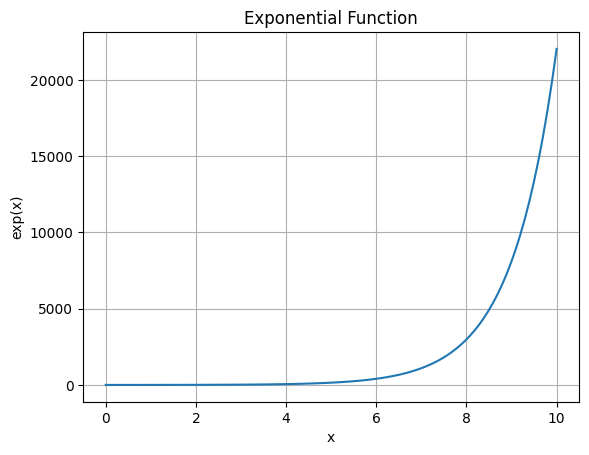

In [7]:
y = tc.exp(x)

import matplotlib.pyplot as plt

plt.plot(x.numpy(), y.numpy()) # here why .numpy()? bcz matplotlib works with numpy arrays
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Exponential Function')
plt.grid(True)
plt.show()

In [8]:
x = tc.tensor(1.0, requires_grad=True)
z = tc.tensor(2.0, requires_grad=True)
y = 9*x**4 + z**3
y.backward() # compute the derivative
x.grad # dy/dx at x=1.0

tensor(36.)

In [9]:
z.grad

tensor(12.)

In [10]:
#MLP using NN
# feed forwad --backpo
w = tc.tensor(3.0, requires_grad=True)
b = tc.tensor(1.0, requires_grad=True)

In [11]:
def forward(x):
    y = w * x + b
    return y

x = tc.tensor([[2.2],[3.2]])
y = forward(x)
y

tensor([[ 7.6000],
        [10.6000]], grad_fn=<AddBackward0>)

In [12]:
from torch.nn import Linear
model = Linear(1, 1) # https://pytorch.org/docs/stable/nn.html#torch.nn.Linear

In [13]:
model.weight

Parameter containing:
tensor([[-0.2249]], requires_grad=True)

In [14]:
x = tc.tensor([[2.2],[3.2]])
y = model(x)
y

tensor([[ 0.2147],
        [-0.0101]], grad_fn=<AddmmBackward0>)

In [18]:
# cusotm modules
class LR(tc.nn.Module):
    def __init__(self,input_size, output_size):
        super().__init__()
        self.model = Linear(input_size, output_size) # https://pytorch.org/docs/stable/nn.html#torch.nn.Linear
        self.weight = self.model.weight
    def forward(self,x):
        pred = self.model(x)
        prob = tc.sigmoid(pred)
        return prob


model = LR(2,1)
x = tc.tensor([[2.0,3.0],[4.0,5.0]])
model.forward(x)

tensor([[0.8865],
        [0.9627]], grad_fn=<SigmoidBackward0>)

In [19]:
model.weight

Parameter containing:
tensor([[-0.0412,  0.6394]], requires_grad=True)

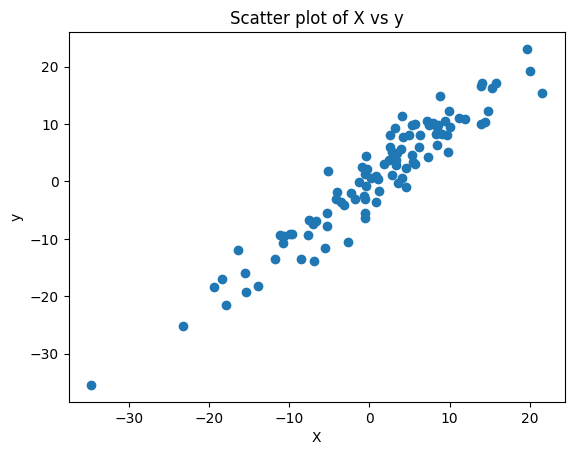

In [37]:
# Creating dataset
import matplotlib.pyplot as plt
X= tc.randn(100, 1)*10    # 100 samples, 1 feature
y=X + 3*tc.randn(100, 1)
# print(X) # small variance so ? lets make some
plt.plot(X.numpy(), y.numpy(), 'o')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot of X vs y")
plt.show()


In [38]:
class LR(tc.nn.Module): #torch.nn.Module ? https://pytorch.org/docs/stable/generated/torch.nn.Module.html why we have this ? because it provides a way to define and manage the parameters of the model.
    def __init__(self,input_size,output_size):
        super().__init__() # initialize the parent class ? where is it defined? https://pytorch.org/docs/stable/generated/torch.nn.Module.html
        self.model = tc.nn.Linear(input_size, output_size)

    def forward(self, x):
        pred = self.model(x) # later one sigmoid
        return pred

In [39]:
model = LR(1,1)
[w,b]= model.parameters()

In [40]:
def get_parameters():
    return w[0][0].item(), b[0].item()

In [ ]:
get_parameters()

# 0.9543270468711853, -0.15655148029327393)

(-0.5509341955184937, -0.21731555461883545)

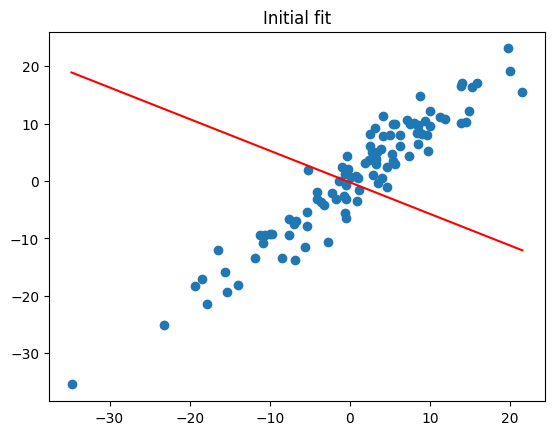

In [42]:
def plot_fit(title):
   plt.title(title)
   w1, b1 = get_parameters()
   x1= np.array([X.min(), X.max()])
   y1= w1*x1 + b1
   plt.plot(x1, y1, 'r')
   plt.scatter(X,y)

plot_fit("Initial fit")

In [31]:
# need to fine tune : Gradient Descent
# what is gradient descent ?
# Gradient Descent is an optimization algorithm used 
# to minimize a loss function by iteratively adjusting the model parameters in 
# the direction of the negative gradient.
# what is  negative gradient ?
# The negative gradient is the vector that points in the direction of the steepest decrease of the loss function.
# You need to define your loss function and 
# compute its gradient with respect to the model parameters.
# need to iterate till convergence

In [43]:
#step 1 : Define the loss function
criterion = tc.nn.MSELoss()

optimizer = tc.optim.SGD(model.parameters(), lr=0.01) 
# difference between Gradient Descent and Stochastic Gradient Descent
# Gradient Descent computes the gradient using the entire dataset,
# while Stochastic Gradient Descent (SGD) updates the model using a single data point.
# Mini-batch Gradient Descent is a compromise between the two,
# using a small random subset of the data to compute the gradient.

epochs = 40

losses= []
for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)
    losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs} Loss: {loss.item()}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



Epoch 1/40 Loss: 249.48419189453125
Epoch 2/40 Loss: 215.2314453125
Epoch 3/40 Loss: 185.87042236328125
Epoch 4/40 Loss: 160.70278930664062
Epoch 5/40 Loss: 139.12957763671875
Epoch 6/40 Loss: 120.63733673095703
Epoch 7/40 Loss: 104.78610229492188
Epoch 8/40 Loss: 91.1987075805664
Epoch 9/40 Loss: 79.55179595947266
Epoch 10/40 Loss: 69.56822204589844
Epoch 11/40 Loss: 61.010498046875
Epoch 12/40 Loss: 53.67494583129883
Epoch 13/40 Loss: 47.387020111083984
Epoch 14/40 Loss: 41.99711990356445
Epoch 15/40 Loss: 37.376983642578125
Epoch 16/40 Loss: 33.41667556762695
Epoch 17/40 Loss: 30.021957397460938
Epoch 18/40 Loss: 27.112051010131836
Epoch 19/40 Loss: 24.617713928222656
Epoch 20/40 Loss: 22.47960662841797
Epoch 21/40 Loss: 20.646841049194336
Epoch 22/40 Loss: 19.075822830200195
Epoch 23/40 Loss: 17.729154586791992
Epoch 24/40 Loss: 16.574804306030273
Epoch 25/40 Loss: 15.585308074951172
Epoch 26/40 Loss: 14.737113952636719
Epoch 27/40 Loss: 14.010048866271973
Epoch 28/40 Loss: 13.3868

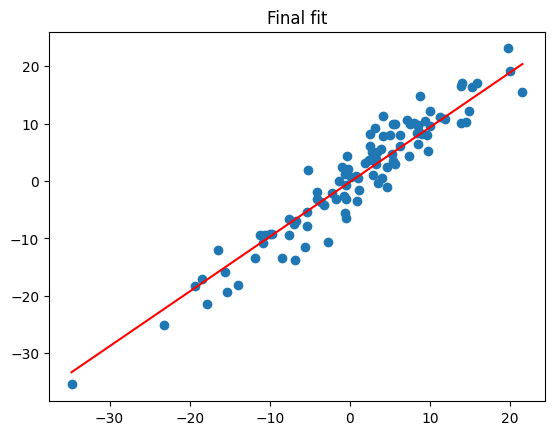

In [44]:
plot_fit("Final fit")
plt.show()

In [45]:
get_parameters()

(0.9543270468711853, -0.15655148029327393)

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim


In [47]:
# Generate a smooth time series
t = torch.linspace(0, 60, steps=500)
signal = torch.sin(t * 0.2) + 0.1 * torch.randn_like(t)

# Build sequences
seq_len = 20
X = []
y = []
for i in range(len(signal) - seq_len):
    X.append(signal[i:i+seq_len])
    y.append(signal[i+seq_len])
X = torch.stack(X)              # (N, seq_len)
y = torch.stack(y).unsqueeze(1) # (N, 1)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print('X_train:', X_train.shape, 'y_train:', y_train.shape)

X_train: torch.Size([384, 20]) y_train: torch.Size([384, 1])


In [48]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Sigmoid(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)
    

    

In [49]:
mlp = MLP(input_size=seq_len, hidden_size=64, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

In [50]:
for epoch in range(80):
    mlp.train()
    optimizer.zero_grad()
    preds = mlp(X_train)
    loss = criterion(preds, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f'MLP epoch {epoch+1}: loss={loss.item():.4f}')

MLP epoch 20: loss=0.1437
MLP epoch 40: loss=0.0491
MLP epoch 60: loss=0.0408
MLP epoch 80: loss=0.0388


In [51]:
mlp.eval()
with torch.no_grad():
    test_loss = criterion(mlp(X_test), y_test)
print('MLP test loss:', test_loss.item())

MLP test loss: 0.028155619278550148


In [ ]:
# https://github.com/CSCfi/machine-learning-scripts/blob/master/notebooks/pytorch-mnist-mlp.ipynb